# Unit 4 — Notebook 3: Comparing AWS, Azure, and GCP for ML Deployment

**What you will learn:**
1. The three tiers of cloud ML deployment (IaaS, CaaS, PaaS) and when to use each
2. The concrete differences between AWS SageMaker, GCP Vertex AI, and Azure ML
3. How to estimate monthly serving cost based on request volume
4. What vendor lock-in means and how containerization reduces it

**No cloud credentials needed** — this notebook runs entirely on your local Python environment.

## 🔗 Where this fits

**Builds on:** Course 05 (AIAT 115) — Unit 5, lesson 06 "06. Performance Optimization" — measure first, then choose; the same discipline applied to cloud vendors means comparing service tiers and monthly cost curves instead of trusting a product page.


## 📰 37signals published its cloud bill, then left

Most cloud-cost arguments are anecdotes. 37signals — the company behind Basecamp and HEY — published its numbers. On **19 October 2022** David Heinemeier Hansson announced the company was leaving AWS and Google Cloud (*Why we're leaving the cloud*). Two years later, in **October 2024**, he reported what actually happened: the cloud bill came down **from a $3.2 million/year run rate to $1.3 million**, which he called *"a saving of almost two million dollars per year"*; the replacement Dell hardware cost **about $700,000** and was **entirely recouped during 2023**; and the original estimate of **$7 million saved over five years** now looks like **more than $10 million**. The migration was possible in the first place because the applications ran in containers and were not written against a provider's SDK.

You do not have to agree with their decision to learn the two things it demonstrates. **One:** for steady, predictable load, the cloud's price is a premium paid for elasticity you may not be using. **Two:** the ability to make that choice at all is a property of how you built the thing — which is what the portability spectrum in section 5 is about.

**What goes wrong without this lesson.** Teams pick a platform by default — whichever tutorial they read, whichever cloud has a free tier — and write provider SDK calls directly into their inference code. Three years later the bill is a line item somebody notices, and the estimate for moving is measured in engineer-months, because "the model" turned out to be inseparable from one company's API.

---
## Section 1 — Three Tiers of Cloud ML Deployment

Cloud providers offer ML deployment at three levels of abstraction. The more abstraction, the less you manage — but also the less control you have.

### Tier 1: IaaS — Infrastructure as a Service
You rent a virtual machine (VM). You install Docker, your app, your dependencies. You manage everything above the hypervisor.

- **Examples:** AWS EC2, GCP Compute Engine, Azure VM
- **You manage:** OS updates, Docker, auto-scaling, health checks, load balancers
- **Good when:** You need full control, or unusual hardware (custom GPU configs)

### Tier 2: CaaS — Containers as a Service
You provide a Docker image. The cloud runs it in a managed container cluster (managed Kubernetes).

- **Examples:** AWS ECS / EKS, GCP GKE, Azure AKS
- **You manage:** Docker image, Kubernetes YAML
- **Good when:** You need K8s power without managing the control plane

### Tier 3: PaaS — Platform as a Service (Managed ML Endpoints)
You provide a model file and a scoring script. The platform handles everything else — containers, auto-scaling, A/B testing, model registry, monitoring.

- **Examples:** AWS SageMaker, GCP Vertex AI, Azure Machine Learning
- **You manage:** Model artifact, inference code
- **Good when:** You want to ship fast and are willing to pay the abstraction tax


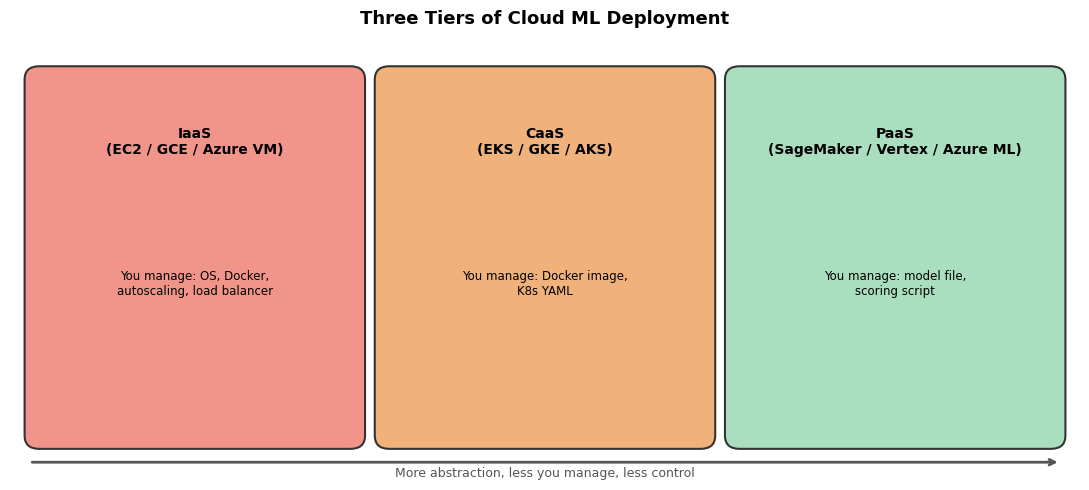

In [1]:
# WHAT: draw the three-tier abstraction ladder: IaaS -> CaaS -> PaaS.
# WHY: every cloud deployment decision starts here — how much do YOU want to
# manage vs hand to the provider? The rest of the lesson compares within tiers.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(11, 5))
ax.set_xlim(0, 11)
ax.set_ylim(0, 5)
ax.axis('off')

# One box per tier: name, what remains your responsibility, and a color.
tiers = [
    (0.3, 'IaaS\n(EC2 / GCE / Azure VM)',
     'You manage: OS, Docker,\nautoscaling, load balancer',
     '#F1948A'),
    (3.9, 'CaaS\n(EKS / GKE / AKS)',
     'You manage: Docker image,\nK8s YAML',
     '#F0B27A'),
    (7.5, 'PaaS\n(SageMaker / Vertex / Azure ML)',
     'You manage: model file,\nscoring script',
     '#A9DFBF'),
]

for x, title, detail, color in tiers:
    rect = mpatches.FancyBboxPatch((x, 0.5), 3.2, 4.0,
                                    boxstyle='round,pad=0.15',
                                    facecolor=color, edgecolor='#333', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + 1.6, 3.8, title, ha='center', va='center', fontsize=10, fontweight='bold')
    ax.text(x + 1.6, 2.2, detail, ha='center', va='center', fontsize=8.5)

# Arrow from IaaS to PaaS: more abstraction →
ax.annotate('', xy=(10.8, 0.2), xytext=(0.2, 0.2),
            arrowprops=dict(arrowstyle='->', lw=2, color='#555'))
ax.text(5.5, 0.0, 'More abstraction, less you manage, less control',
        ha='center', va='bottom', fontsize=9, color='#555')

ax.set_title('Three Tiers of Cloud ML Deployment', fontsize=13, fontweight='bold', pad=8)
plt.tight_layout()
plt.show()

**Read the ladder.** Three boxes, one arrow, and the arrow is doing all the work: left to right
you hand more away and keep less control. The text inside each box is the part to memorise,
because it is the literal answer to "what will I be on call for?" — an OS, a load balancer and
autoscaling rules at IaaS; a Docker image and some YAML at CaaS; a model file and a scoring
script at PaaS.

Nothing here says right is better. Moving right buys you speed and costs you two things: the
ability to tune what you cannot see, and — as the lock-in spectrum at the end of this notebook
shows — the ability to leave. Notebook 01 built the artifact for the middle box and Notebook 02
wrote the YAML for it, so this diploma has deliberately parked you at CaaS: the rung where the
thing you deploy is still a standard container.

---
## Section 2 — Platform Comparison Table

Let's build a structured comparison of the three major PaaS ML platforms using pandas.


In [2]:
# WHAT: a feature-by-feature comparison table of SageMaker, Vertex AI, and Azure ML.
# WHY: the platforms converge on features — the real differences are ecosystem
# fit (last row) and pricing model, which is why 'best for' matters most.
import pandas as pd

data = {
    "Feature": [
        "Auto-scaling",
        "Serving framework",
        "Model registry",
        "Built-in monitoring",
        "MLflow support",
        "Spot / preemptible instances",
        "Supported frameworks",
        "Pricing model",
        "Best for",
    ],
    # One list per platform, aligned with the Feature rows above.
    "AWS SageMaker": [
        "Yes (target tracking)",
        "TorchServe, TF Serving, custom",
        "SageMaker Model Registry",
        "CloudWatch + Model Monitor",
        "Via MLflow tracking server",
        "Yes (Spot training)",
        "TF, PyTorch, sklearn, XGBoost, HuggingFace",
        "Per instance-hour + per GB data",
        "Teams already in AWS ecosystem",
    ],
    # Vertex AI: note the BigQuery/TensorFlow ecosystem emphasis.
    "GCP Vertex AI": [
        "Yes (request-based)",
        "TF Serving, custom container",
        "Vertex Model Registry",
        "Cloud Monitoring + Explainability",
        "Managed MLflow on Vertex",
        "Yes (preemptible VMs)",
        "TF, PyTorch, sklearn, XGBoost",
        "Per vCPU-hour + per GB",
        "TensorFlow workloads; BigQuery integration",
    ],
    # Azure ML: strongest native MLflow story, enterprise Microsoft fit.
    "Azure ML": [
        "Yes (manual + auto rules)",
        "ONNX, TF, PyTorch, custom",
        "Azure ML Model Registry",
        "Application Insights + Data Drift",
        "Native MLflow integration",
        "Yes (low-priority VMs)",
        "TF, PyTorch, sklearn, ONNX",
        "Per compute-hour + storage",
        "Enterprise Microsoft/Azure stack",
    ],
}

# Features as rows, platforms as columns — read DOWN a column to profile one platform.
df = pd.DataFrame(data)
df = df.set_index("Feature")

# Display with styling
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.width', 120)
print(df.to_string())

                                                           AWS SageMaker                               GCP Vertex AI                           Azure ML
Feature                                                                                                                                                
Auto-scaling                                       Yes (target tracking)                         Yes (request-based)          Yes (manual + auto rules)
Serving framework                         TorchServe, TF Serving, custom                TF Serving, custom container          ONNX, TF, PyTorch, custom
Model registry                                  SageMaker Model Registry                       Vertex Model Registry            Azure ML Model Registry
Built-in monitoring                           CloudWatch + Model Monitor           Cloud Monitoring + Explainability  Application Insights + Data Drift
MLflow support                                Via MLflow tracking server                

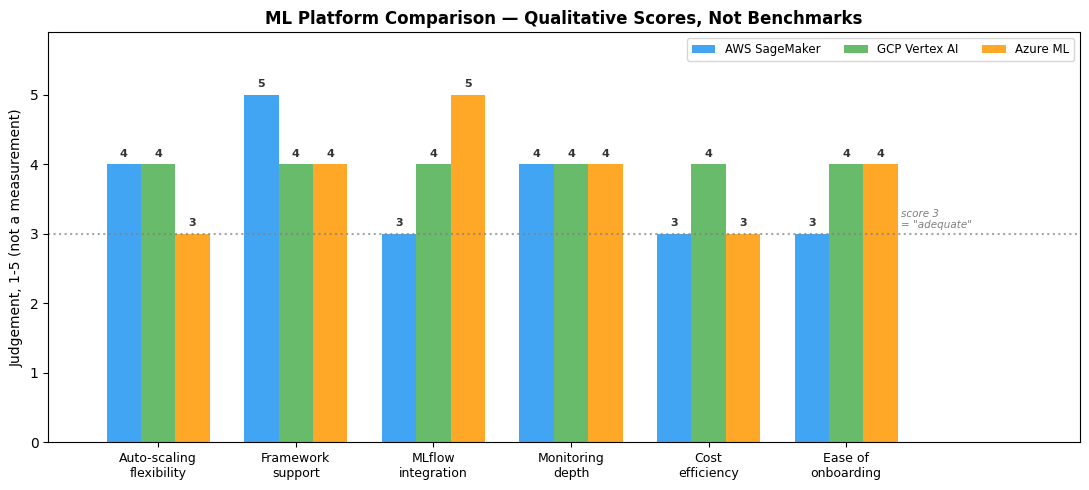

Note: scores are illustrative based on documentation and community feedback.
Evaluate against your specific workload before choosing.


In [3]:
# Visualise a qualitative score comparison across key dimensions
import matplotlib.pyplot as plt
import numpy as np

categories = [
    'Auto-scaling\nflexibility',
    'Framework\nsupport',
    'MLflow\nintegration',
    'Monitoring\ndepth',
    'Cost\nefficiency',
    'Ease of\nonboarding',
]

# Scores out of 5 (illustrative, based on documentation depth and community reports)
# Honest labeling: these are qualitative 1-5 judgments, not measurements.
scores = {
    'AWS SageMaker': [4, 5, 3, 4, 3, 3],
    'GCP Vertex AI': [4, 4, 4, 4, 4, 4],
    'Azure ML':      [3, 4, 5, 4, 3, 4],
}

# Grouped bars: one cluster per dimension, one color per platform.
x = np.arange(len(categories))
width = 0.25
fig, ax = plt.subplots(figsize=(11, 5))

colors = ['#2196F3', '#4CAF50', '#FF9800']
for i, (platform, vals) in enumerate(scores.items()):
    ax.bar(x + i * width, vals, width, label=platform, color=colors[i], alpha=0.85)

# Print the number on every bar: these differ by one point at most, and one
# point of bar height is hard to read from the back of a room.
for i, vals in enumerate(scores.values()):
    for xi, v in zip(x, vals):
        ax.text(xi + i * width, v + 0.08, str(v), ha='center', va='bottom',
                fontsize=8, fontweight='bold', color='#333')

ax.set_xticks(x + width)
ax.set_xticklabels(categories, fontsize=9)
ax.set_ylim(0, 5.9)
ax.set_yticks(range(6))
ax.set_ylabel('Judgement, 1-5 (not a measurement)')
ax.set_title('ML Platform Comparison — Qualitative Scores, Not Benchmarks',
             fontsize=12, fontweight='bold')
ax.legend(loc='upper right', ncol=3, fontsize=8.5)
# Say what the reference line means, instead of leaving an unlabelled dotted line.
ax.axhline(3, color='gray', linestyle=':', alpha=0.7)
# Park the label in a clear right-hand margin: over the plot it landed on the
# last cluster's bars and its value labels.
ax.set_xlim(-0.55, len(categories) + 0.95)
ax.text(len(categories) - 0.35, 3.05, 'score 3\n= "adequate"', fontsize=7.5,
        color='gray', style='italic', ha='left', va='bottom')
plt.tight_layout()
plt.show()

print("Note: scores are illustrative based on documentation and community feedback.")
print("Evaluate against your specific workload before choosing.")

**Read the chart — and read what it is not.** Every bar is a judgement between 1 and 5, printed
on top of the bar because the whole chart spans two points and one point of height is invisible
from the back of a room. Nothing here was benchmarked.

With that said, the shape is the message: **the bars are almost level.** Across six dimensions
and three platforms, nothing scores below 3 and nothing above 5. The platforms have converged —
each has autoscaling, a model registry, monitoring, and broad framework support, so a feature
grid will not choose for you. The two visible tilts are the ones with real causes: Azure ML
leads on MLflow because it ships MLflow as its native tracking API, and SageMaker leads on
framework support because it has been shipping serving containers the longest.

If your decision hangs on differences this small, you are asking the wrong question. The
variables that actually decide it are the last row of the table above — which cloud your data
and your team already live in — and the cost curve in the next section.

---
## Section 3 — Decision Tree: Choosing a Platform

Use this flowchart to guide your choice. Start at the top.

```
Is your team already invested in one cloud provider's services?
  ├─ Yes, AWS  → Start with SageMaker. Use Spot instances for training.
  ├─ Yes, GCP  → Start with Vertex AI. Best TensorFlow support + BigQuery integration.
  └─ Yes, Azure / Microsoft stack → Azure ML. Native MLflow, Active Directory integration.

Do you need maximum control over the serving infrastructure?
  └─ Yes → Self-managed Kubernetes (EKS / GKE / AKS).
           You write K8s YAML (like Notebook 02) and own every config.

Do you need to deploy in <1 day with no DevOps team?
  └─ Yes → Any managed endpoint (SageMaker, Vertex, Azure ML).
           They handle the container, load balancer, and auto-scaling for you.

Are you multi-cloud or open-source first?
  └─ Yes → Docker + Kubernetes on any cloud.
           Your images are portable. Avoid platform-specific SDKs in inference code.
```


---
## Section 4 — Cost Estimation

Cloud serving costs depend on: how many requests per day, how long each takes (which determines how many instances you need), and the instance type cost. The function below estimates monthly cost for a given workload.


In [4]:
# WHAT: a cost model — from daily requests to instance count to monthly dollars,
# evaluated for light, heavy, and GPU workloads.
# WHY: the pattern (peak RPS -> instances -> redundancy -> hours) is how real
# capacity planning works on ANY provider; only the hourly rates change.
def estimate_monthly_cost(
    requests_per_day: int,
    avg_latency_ms: float,
    instance_cost_per_hour: float,
    requests_per_instance_per_second: float = 50.0,
    redundancy_factor: float = 1.5,
    label: str = ""
) -> dict:
    """
    Estimate monthly serving cost.

    Parameters
    ----------
    requests_per_day          : total daily requests
    avg_latency_ms            : average inference latency in milliseconds
    instance_cost_per_hour    : cost of one inference instance (USD/hr)
    requests_per_instance_per_second : throughput per instance
    redundancy_factor         : multiply instance count for HA (1.5 = 50% extra)
    label                     : name for this scenario
    """
    # Peak requests per second (assuming traffic concentrated in 8 hours)
    peak_rps = requests_per_day / (8 * 3600)

    # Minimum instances needed to handle peak
    instances_needed = max(1, peak_rps / requests_per_instance_per_second)

    # Apply redundancy for high availability
    instances_with_ha = instances_needed * redundancy_factor

    # Monthly cost (730 hours/month)
    monthly_cost = instances_with_ha * instance_cost_per_hour * 730

    return {
        "scenario": label,
        "requests_per_day": requests_per_day,
        "peak_rps": round(peak_rps, 2),
        "instances_needed": round(instances_with_ha, 1),
        "monthly_cost_usd": round(monthly_cost, 2),
    }


# Light workload: a small internal tool or demo
light = estimate_monthly_cost(
    requests_per_day=10_000,
    avg_latency_ms=20,
    instance_cost_per_hour=0.12,   # e.g., ml.t2.medium on SageMaker
    label="Light (10K req/day)"
)

# Heavy workload: production consumer-facing API
heavy = estimate_monthly_cost(
    requests_per_day=1_000_000,
    avg_latency_ms=20,
    instance_cost_per_hour=0.12,
    label="Heavy (1M req/day)"
)

# GPU workload: large model inference
gpu = estimate_monthly_cost(
    requests_per_day=100_000,
    avg_latency_ms=80,
    instance_cost_per_hour=2.10,   # e.g., ml.g4dn.xlarge
    requests_per_instance_per_second=10,
    label="GPU (100K req/day, large model)"
)

# Put the three scenarios side by side — note how instance price and
# throughput drive cost more than raw request count.
import pandas as pd
results = pd.DataFrame([light, heavy, gpu])
print(results.to_string(index=False))
print()
print("These are rough estimates. Actual costs depend on data transfer, storage,")
print("monitoring, and whether you use reserved vs on-demand pricing.")

                       scenario  requests_per_day  peak_rps  instances_needed  monthly_cost_usd
            Light (10K req/day)             10000      0.35               1.5             131.4
             Heavy (1M req/day)           1000000     34.72               1.5             131.4
GPU (100K req/day, large model)            100000      3.47               1.5            2299.5

These are rough estimates. Actual costs depend on data transfer, storage,
monitoring, and whether you use reserved vs on-demand pricing.


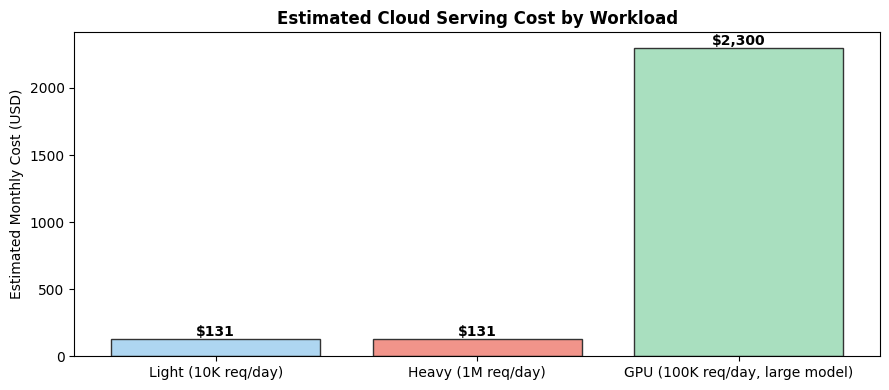

In [5]:
# WHAT: bar-chart the three scenario costs from the previous cell.
# WHY: seeing GPU inference cost rival a 100x-traffic CPU workload makes the
# 'right-size your instance' lesson stick better than the table alone.
import matplotlib.pyplot as plt

scenarios = [light, heavy, gpu]
labels = [s["scenario"] for s in scenarios]
costs = [s["monthly_cost_usd"] for s in scenarios]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(labels, costs, color=['#AED6F1', '#F1948A', '#A9DFBF'], edgecolor='#333')
ax.set_ylabel('Estimated Monthly Cost (USD)')
ax.set_title('Estimated Cloud Serving Cost by Workload', fontweight='bold')

for bar, cost in zip(bars, costs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'${cost:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### The same model, swept across every traffic level

Three bars are three points. The cost model is a *function*, so sweep it: feed
`estimate_monthly_cost` every traffic level from a thousand to a hundred million requests a
day and plot what comes back. A curve exposes things three bars cannot.

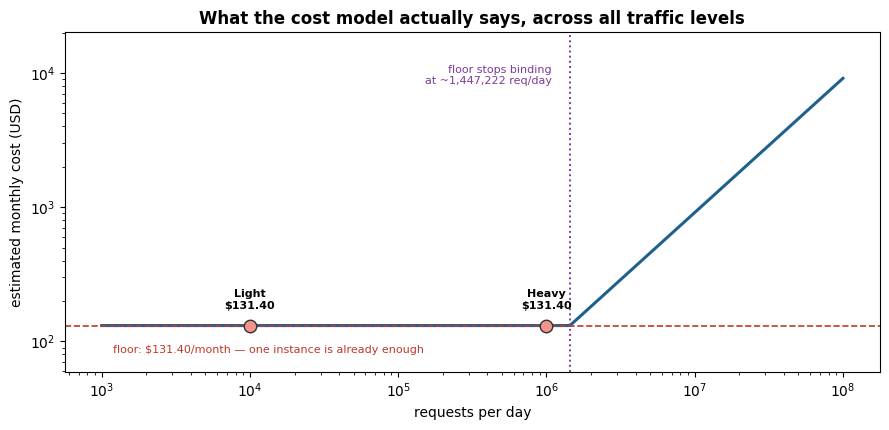

Flat from 1,000 to ~1,447,222 requests/day — a factor of 1,447 in traffic at the same $131.40/month.
The Light and Heavy scenarios are 100x apart in traffic and $0.00 apart in cost.


In [6]:
# WHAT: sweep the SAME cost function over five orders of magnitude of traffic.
# WHY: three scenarios cannot show you the shape of a model. The shape is where its
#      one serious flaw lives — and finding that flaw is the point of this section.
import matplotlib.pyplot as plt
import numpy as np

# Reuse the function defined above, unchanged — same rate, same redundancy factor.
rpd = np.logspace(3, 8, 300)                 # 1e3 .. 1e8 requests per day
costs = np.array([
    estimate_monthly_cost(int(r), avg_latency_ms=20,
                          instance_cost_per_hour=0.12)["monthly_cost_usd"]
    for r in rpd
])

floor = costs.min()
# Where does the max(1, ...) floor stop binding? First traffic level that costs more.
knee_idx = int(np.argmax(costs > floor * 1.001))
knee = rpd[knee_idx]

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(rpd, costs, color="#1F618D", lw=2.2)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("requests per day")
ax.set_ylabel("estimated monthly cost (USD)")
ax.set_title("What the cost model actually says, across all traffic levels",
             fontweight="bold")

# Give the annotations room above and below the flat stretch.
ax.set_ylim(floor * 0.45, costs.max() * 2.2)

# The flat stretch, and the two scenarios that both sit on it.
ax.axhline(floor, color="#C0392B", ls="--", lw=1.2)
ax.text(1.2e3, floor * 0.62, f"floor: ${floor:,.2f}/month — one instance is already enough",
        fontsize=8, color="#C0392B")
ax.axvline(knee, color="#7D3C98", ls=":", lw=1.4)
ax.text(knee * 0.75, costs.max() * 0.9, f"floor stops binding\nat ~{knee:,.0f} req/day",
        fontsize=8, color="#7D3C98", ha="right")

for point, name in ((light, "Light"), (heavy, "Heavy")):
    ax.plot(point["requests_per_day"], point["monthly_cost_usd"], "o",
            ms=9, color="#F1948A", markeredgecolor="#333", zorder=5)
    ax.annotate(f'{name}\n${point["monthly_cost_usd"]:,.2f}',
                (point["requests_per_day"], point["monthly_cost_usd"]),
                textcoords="offset points", xytext=(0, 12), ha="center", fontsize=8,
                fontweight="bold")

plt.tight_layout()
plt.show()

span = heavy["requests_per_day"] / light["requests_per_day"]
print(f"Flat from {rpd[0]:,.0f} to ~{knee:,.0f} requests/day — a factor of "
      f"{knee / rpd[0]:,.0f} in traffic at the same ${floor:,.2f}/month.")
print(f"The Light and Heavy scenarios are {span:,.0f}x apart in traffic and "
      f"${heavy['monthly_cost_usd'] - light['monthly_cost_usd']:,.2f} apart in cost.")


**Read the curve.** It is a flat line and then a straight line, and almost every workload a
student will ever build lives on the flat part. Both scenarios from the table sit on it — the
dots are 100× apart horizontally and at exactly the same height. The dotted line marks where
`max(1, peak_rps / 50)` finally exceeds 1; only to its right does the model respond to traffic
at all.

So the model is not broken, it is *saturated*, and it is saying something true: for a small
scikit-learn service, **your bill is set by how many instances you keep alive for redundancy,
not by how many requests you serve**. That is why the redundancy factor and the instance price
— not the request count — are the two numbers worth arguing about in the Discuss section below.
It is also exactly why this skeleton would mislead you on the GPU row, where a single instance
costs 17× more and the flat part of the curve is 17× higher.

## 💬 Discuss

Look hard at the cost table, because it contains an instructive flaw. The light workload (10,000 requests/day) and the heavy workload (1,000,000 requests/day) both come out at **1.5 instances and $131.40 a month** — a hundredfold traffic increase for free.

1. Find the reason in the function. (`instances_needed = max(1, peak_rps / 50)`; the heavy scenario's peak is 34.72 rps.) Is the model wrong, or is it telling you something true about small ML services? What would you have to change to make it informative for a decision?
2. The GPU scenario costs **$2,299.50/month** at only 100,000 requests/day — 17× the CPU cost for a tenth of the traffic. Sketch the decision you would put to a client who wants a large model: what would have to be true for that gap to be worth paying?
3. 37signals could leave because their code was not written against a provider SDK. Take the SageMaker notebook from Unit 3 and identify exactly which lines would have to change to run the same model on Vertex AI. Now do the same for the Docker image from notebook 01. What does that comparison tell you about where to put provider-specific code?

---
## Section 5 — Vendor Lock-In and Portability

**Vendor lock-in** means your application becomes so dependent on one cloud provider's specific APIs and services that switching is prohibitively expensive.

For ML deployment, lock-in risk increases when you:
- Use provider-specific inference containers (e.g., SageMaker's built-in TF container with SageMaker-only configuration)
- Store model artifacts in proprietary format tied to the provider's registry
- Call provider SDKs (`boto3.client('sagemaker')`) directly in your inference code

**How containerization reduces lock-in:**

If your model runs in a standard Docker container with a plain HTTP API (like Notebook 01), you can move it to any cloud or on-premise server with minimal changes. The container is the portability layer.

### Portability Spectrum


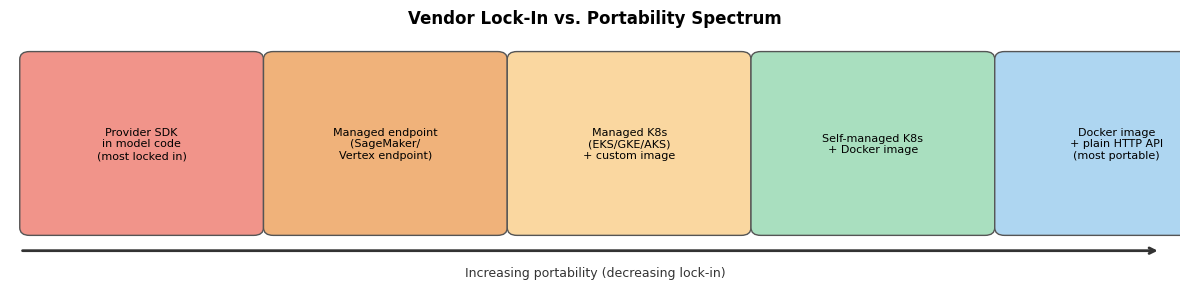

Key rule: keep provider-specific code outside your inference logic.
Inference code should only read a model file and return predictions.


In [7]:
# WHAT: draw the lock-in spectrum — provider SDK in code (locked) to plain
# Docker + HTTP (portable).
# WHY: portability is an architectural choice made BEFORE deployment; the
# closing rule (keep provider code out of inference logic) is the takeaway.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 3))
ax.set_xlim(0, 12)
ax.set_ylim(0, 3)
ax.axis('off')

# Left to right: each option trades provider convenience for portability.
items = [
    (0.2,  '#F1948A', 'Provider SDK\nin model code\n(most locked in)'),
    (2.7,  '#F0B27A', 'Managed endpoint\n(SageMaker/\nVertex endpoint)'),
    (5.2,  '#FAD7A0', 'Managed K8s\n(EKS/GKE/AKS)\n+ custom image'),
    (7.7,  '#A9DFBF', 'Self-managed K8s\n+ Docker image'),
    (10.2, '#AED6F1', 'Docker image\n+ plain HTTP API\n(most portable)'),
]

for x, color, label in items:
    rect = mpatches.FancyBboxPatch((x, 0.4), 2.3, 2.2,
                                    boxstyle='round,pad=0.1',
                                    facecolor=color, edgecolor='#555', linewidth=1)
    ax.add_patch(rect)
    ax.text(x + 1.15, 1.5, label, ha='center', va='center', fontsize=8)

ax.annotate('', xy=(11.8, 0.1), xytext=(0.1, 0.1),
            arrowprops=dict(arrowstyle='->', lw=2, color='#333'))
ax.text(6.0, -0.1, 'Increasing portability (decreasing lock-in)',
        ha='center', va='top', fontsize=9, color='#333')

ax.set_title('Vendor Lock-In vs. Portability Spectrum', fontsize=12, fontweight='bold', pad=4)
plt.tight_layout()
plt.show()

print("Key rule: keep provider-specific code outside your inference logic.")
print("Inference code should only read a model file and return predictions.")

**Read the spectrum.** One axis, five stops, and the axis is the trade you are actually
making: everything you gain in provider convenience going left, you pay for in portability.
The far left is not a strawman — `boto3.client("sagemaker")` inside your inference function is
the normal way SageMaker examples are written, and it welds the model to one vendor. The far
right is precisely what Notebook 01 built: a Docker image speaking plain HTTP, which runs on
EC2, on GKE, on a laptop, or on 37signals' own Dell hardware without a line changing.

The two middle stops are where most real teams end up, and the picture explains why: a managed
Kubernetes service takes the cluster operations off your hands while the thing you deploy stays
a standard image. Read this next to the ladder in Section 1 and notice they are *not* the same
axis — moving up the abstraction ladder usually moves you left here, and deciding how much of
that you will accept is an architecture decision you make before you deploy, not after.

---
## Summary

Choosing a cloud platform for ML deployment comes down to three variables:

1. **Your existing infrastructure** — if your team is already on AWS, SageMaker is the path of least resistance. Cross-cloud migrations are expensive.
2. **Your control requirements** — PaaS is fastest to deploy; self-managed K8s gives the most tuning control.
3. **Your cost model** — per-prediction pricing (SageMaker serverless, Vertex online prediction) is great for variable traffic; per-hour is better for steady high-volume workloads.

Containerizing your model with Docker (Notebook 01) keeps your options open regardless of which platform you start with.

**Next:** Notebook 04 covers CI/CD — how to automate the entire pipeline from code commit to deployed model.


---
## Self-Check Questions

1. **If you need to deploy a PyTorch model with minimal infrastructure management, which service would you start with on AWS?**
   *(Hint: which tier and which specific service name?)*

2. **What is vendor lock-in and how does containerization reduce it?**
   *(Hint: think about what changes when you move a Docker container vs. a SageMaker-specific endpoint to a different cloud.)*

3. **Why is pricing per-prediction different from pricing per-hour, and which is better for bursty traffic?**
   *(Hint: think about what you pay during periods of zero traffic.)*


## ⚠️ Where this breaks

- **The cost model is a teaching skeleton, not a quote.** It prices instance-hours only, floors the instance count at one, assumes traffic is concentrated in 8 hours, and — as the table above shows — cannot distinguish 10K from 1M requests a day. Real invoices are dominated by things it does not model: egress, storage, logging ingestion, load balancers, and support plans.
- **The platform scores in section 2 are illustrative, and the notebook says so.** They are not measurements. Any real comparison has to be run against *your* workload, and providers change their offerings faster than any table can be maintained.
- **Containers give you portability of the runtime, not of the platform.** Moving a Docker image between clouds is easy. Moving the things around it — IAM, VPCs, managed databases, feature stores, monitoring, autoscaling policies, CI runners — is where migrations actually spend their time. "We use containers, so we are not locked in" is true about a smaller fraction of the system than people assume.
- **The assumption that must hold for a repatriation like 37signals':** you have, or can hire, people who run hardware. They are a company with that capability and predictable load. A four-person startup with spiky traffic and no systems administrator is exactly who the cloud's premium is *for*. The lesson is that the trade should be measured, not that on-premise wins.
- **Cross-provider portability has a cost you pay continuously.** Refusing every managed service to stay portable means re-implementing autoscaling, model registries and monitoring yourself. That is a real bill in engineer-time, charged every month, against a migration that may never happen.
- **The cheaper alternative to all of this analysis.** If your organisation already has one cloud, the decision is made; spend the effort on keeping provider-specific code out of the inference path — a single adapter module rather than SDK calls scattered through the service — and you preserve the option at almost no cost.

## 🔭 State of the field (2026)

The three-column comparison this notebook builds is the right comparison, and in 2026 it wants a
fourth column. Open-weight releases plus bandwidth-adaptive serving now place large
mixture-of-experts models on ordinary heterogeneous local hardware, adapting computation and model
placement to whatever machine is available instead of assuming a rented accelerator (Yang et al.,
2026, arXiv:2608.16157) — which turns "run it on our own machines" from a rhetorical option into a
priceable one. The second 2026 change sits *inside* the container rather than around it: what
actually serves the model is no longer a given, and a 2025 survey compares 25 open-source and
commercial inference engines on optimization, deployment ease, scalability and hardware support
(Park et al., 2025, arXiv:2505.01658), which is an evidence-based choice rather than one inherited
from a tutorial.

Neither change removes the skill taught here; both depend on it. You cannot argue for an on-premise
or edge deployment without exactly the artefacts this notebook produces — the abstraction ladder,
the monthly cost curve, and the lock-in spectrum that says where provider-specific code may live —
which is precisely what 37signals published before they left. Add the fourth column to the table
and re-run the cost model against it; the AWS/Azure/GCP comparison the official plan examines is
unchanged, only better bounded.

## 📚 References

1. Armbrust, M., Fox, A., Griffith, R., et al. (2010). *A View of Cloud Computing*. Communications of the ACM 53(4).
2. Paleyes, A., Urma, R.-G., & Lawrence, N. D. (2022). *Challenges in Deploying Machine Learning: A Survey of Case Studies*. ACM Computing Surveys. <https://arxiv.org/abs/2011.09926>
3. Kreuzberger, D., Kühl, N., & Hirschl, S. (2022). *Machine Learning Operations (MLOps): Overview, Definition, and Architecture*. IEEE Access. <https://arxiv.org/abs/2205.02302>
4. Park, S., Jeon, S., Lee, C., Jeon, S., Kim, B.-S., & Lee, J. (2025). *A Survey on Inference Engines for Large Language Models: Perspectives on Optimization and Efficiency*. arXiv:2505.01658. <https://arxiv.org/abs/2505.01658>
5. Yang, S., Fan, X., Pan, M., et al. (2026). *FreeToken: Efficient Edge-Native MoE Serving with Bandwidth-Adaptive Execution*. arXiv:2608.16157. <https://arxiv.org/abs/2608.16157>